
--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   t            100 non-null    int64
 1   ProductP1    100 non-null    int64
 2   ProductP2    100 non-null    int64
 3   ProductP3    100 non-null    int64
 4   ProductP4    100 non-null    int64
 5   ProductP5    100 non-null    int64
 6   price        100 non-null    int64
 7   temperature  100 non-null    int64
dtypes: int64(8)
memory usage: 6.4 KB

--- Checking Missing Values ---
t              0
ProductP1      0
ProductP2      0
ProductP3      0
ProductP4      0
ProductP5      0
price          0
temperature    0
dtype: int64

--- Checking Duplicates ---
0

--- Summary Statistics ---
                t   ProductP1   ProductP2  ProductP3   ProductP4   ProductP5  \
count  100.000000  100.000000  100.000000   100.0000  100.000000  100.000000   
mean    50.500000  148.370000  153.4

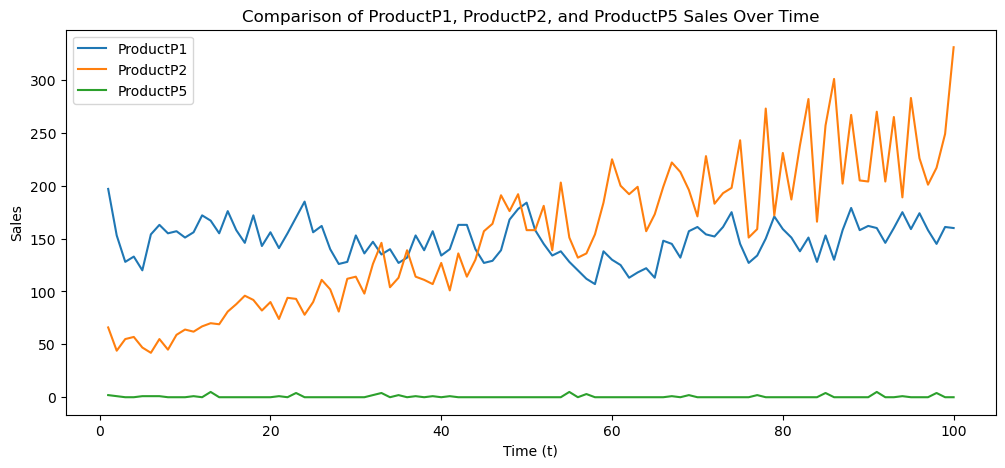

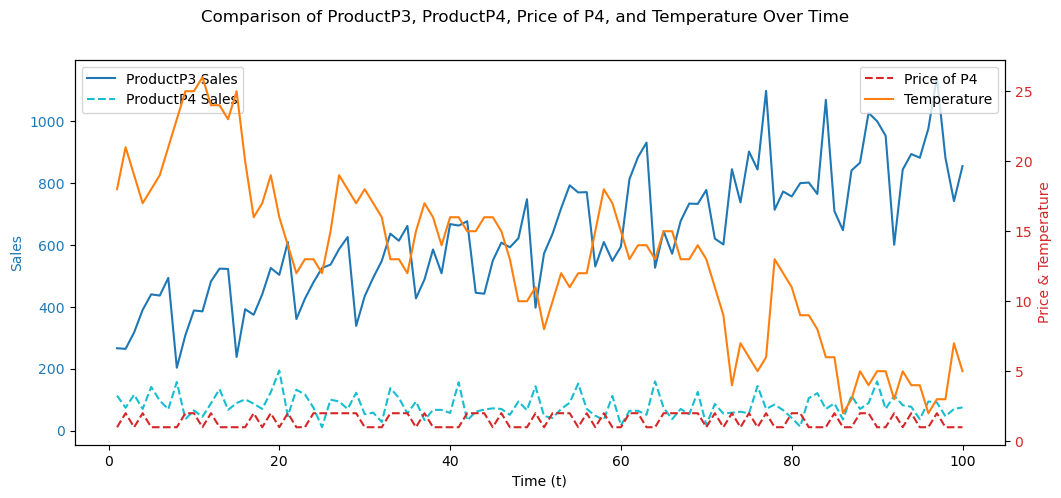

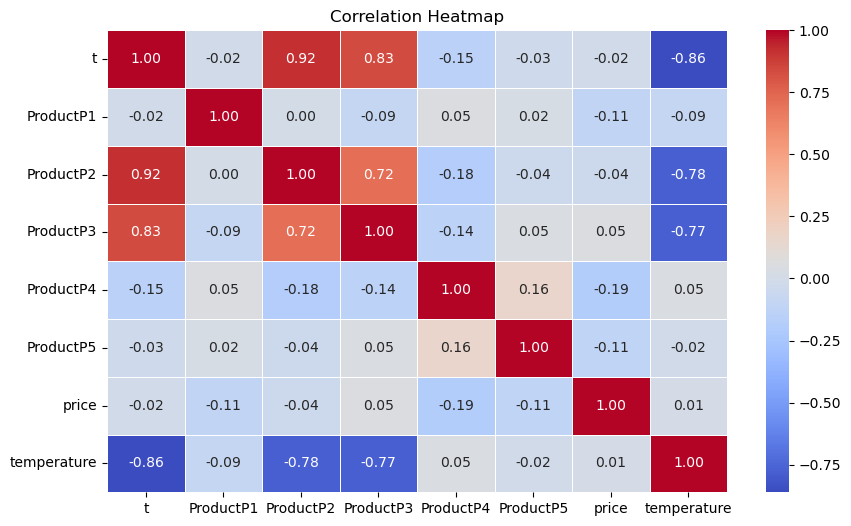

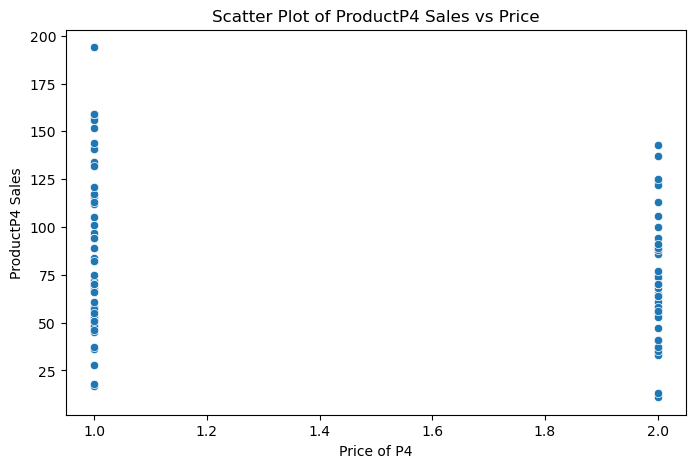

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX

df = pd.read_csv("time_series_data.csv")

# 1. Data Cleaning & Preprocessing
print("\n--- Dataset Info ---")
df.info()
print("\n--- Checking Missing Values ---")
print(df.isnull().sum())
print("\n--- Checking Duplicates ---")
print(df.duplicated().sum())
print("\n--- Summary Statistics ---")
print(df.describe())

# 2. Compare P1, P2, P5 Sales Trends
plt.figure(figsize=(12, 5))
for product in ["ProductP1", "ProductP2", "ProductP5"]:
    plt.plot(df["t"], df[product], label=product)
plt.xlabel("Time (t)")
plt.ylabel("Sales")
plt.title("Comparison of ProductP1, ProductP2, and ProductP5 Sales Over Time")
plt.legend()
plt.show()

# 3. Compare P3, P4, Price of P4, and Temperature Over Time
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.set_xlabel("Time (t)")
ax1.set_ylabel("Sales", color="tab:blue")
ax1.plot(df["t"], df["ProductP3"], label="ProductP3 Sales", color="tab:blue")
ax1.plot(df["t"], df["ProductP4"], label="ProductP4 Sales", color="tab:cyan", linestyle="dashed")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax2 = ax1.twinx()
ax2.set_ylabel("Price & Temperature", color="tab:red")
ax2.plot(df["t"], df["price"], label="Price of P4", color="tab:red", linestyle="dashed")
ax2.plot(df["t"], df["temperature"], label="Temperature", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:red")
fig.suptitle("Comparison of ProductP3, ProductP4, Price of P4, and Temperature Over Time")
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.show()

# 4. Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

# 5. Scatter Plot of ProductP4 vs Price
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df["price"], y=df["ProductP4"])
plt.xlabel("Price of P4")
plt.ylabel("ProductP4 Sales")
plt.title("Scatter Plot of ProductP4 Sales vs Price")
plt.show()

